# Above-Ground Biomass Change Analysis

For a more general introduction to CCI Biomass Data, see the notebook [here](https://climate.esa.int/en/projects/biomass/notebook-biomass/).

📚 For a broader introduction to the toolbox and how to install it, visit:  
🔗 [ESA CCI Climate Toolbox Quick Start](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks)  
🔗 [ESA Climate Data Toolbox Website](https://climate.esa.int/en/data/toolbox/)

### Step 1: Import Necessary Packages and Connect to the ESA CCI Data Store

In this section, we import the required Python packages to work with ESA Climate Change Initiative (CCI) data. Most notably, we use the [ESA Climate Toolbox](https://esa-climate-toolbox.readthedocs.io/en/latest/) which simplifies access, manipulation, and visualization of CCI datasets in Python.

These packages allow us to:
- Access satellite-based climate data records from ESA.
- Handle geospatial and temporal dimensions efficiently.
- Visualize data with intuitive plotting tools.

In [ ]:
#%pip install esa-climate-toolbox

In [ ]:
from xcube.core.store import new_data_store
from esa_climate_toolbox.core import get_op
from esa_climate_toolbox.core import list_ecv_datasets
from esa_climate_toolbox.core import get_store
from esa_climate_toolbox.core import list_datasets
from esa_climate_toolbox.ops import plot
import xarray as xr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") # Suppressing warnings to keep notebook output clean
%matplotlib inline

### Step 2: Get Access to CCI Biomass Data

The ESA Climate Toolbox provides direct access to the **ESA Climate Data Store**, which hosts harmonized satellite-based climate data records produced under the **ESA Climate Change Initiative (CCI)**.

In this step, we establish a connection to the data store so we can browse and open datasets. This connection allows us to access data **without having to download files manually** — a convenient way to explore and analyze large geospatial datasets in cloud-friendly formats such as **Zarr** or **Kerchunk**.

We also specify the dataset ID for the CCI Biomass dataset - which provides **Above-Ground Biomass (AGB) Difference**, derived from a combination of multiple sensors and platforms. AGB is a key Essential Climate Variable (ECV) used to estimate the amount of carbon stored in vegetation, supporting studies related to the global carbon cycle, deforestation, and land use change.

In [3]:
cci_store = new_data_store("esa-cci")

In [13]:
data_id = 'esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.DIFF.7-0.1000m-2020-2010'

In [ ]:
# Run to get a list of all biomass datasets with different products, resolutions, and time ranges
# list_ecv_datasets("Biomass")

### Step 3: Describe Dataset (Check Available Variables and Metadata)

Before loading the full dataset, it’s helpful to **inspect the metadata** to understand its structure. This includes:

- Available variables (e.g., agb, uncertainty estimates)
- Temporal and spatial coverage
- Data format and structure

This step ensures we know what the dataset contains and how to work with it. It also helps confirm that the variable we want to plot or analyze is actually included.

🛠️ Tip: You can use the description to verify variable names, dimensions (e.g., `lat`, `lon`, `time`), and time coverage.

📘 More on dataset structure:  
🔗 [ESA Climate Toolbox – Data Access](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#accessing-data)

In [ ]:
cci_store.describe_data(data_id)

### Step 4: Check Open Parameters for the Dataset

Before opening the dataset, we can inspect which parameters are supported by the **Zarr opener** (e.g., `time_range`, `bbox`, `variable_names`). This step helps ensure that we pass valid arguments when loading data and avoid errors.

The command below lists all expected input parameters and their allowed values for the selected dataset.

In [ ]:
cci_store.get_open_data_params_schema(data_id=data_id, opener_id='dataset:zarr:cciodp')

### Step 5: Define Region, Variables of Interest, and Time Range

Before opening the dataset, we define a few key parameters:

- **Variables**: which data variable(s) to retrieve. In this example we use diff - the difference variable.
- **Region**: spatial region of interest
- **Time range**: the date(s) we want to load - not applicable to DIFF data sets

In [16]:
# Variable to retrieve
variables = ['diff']  # A full list of available variables can be found by running Step 4

# Target region [lon_min, lon_max, lat_min, lat_max]
region_box = [5.5, 15.5, 47.2, 55.1] # Germany

# region_box = [-10, 40, 35, 72] Europe
# region_box = [-125, 24, -76, 49] USA
# region_box = [140, -44, 154, -28] Eastern Australia

### Step 6: Open the Dataset

Now we open the dataset using the selected parameters.  
The ESA Climate Toolbox will download only the necessary data (e.g., variable and time range).
You can always adjust the time range or variables to explore different slices of the dataset.

In [17]:
biomass_ds = cci_store.open_data(
    data_id=data_id,
    variable_names=variables,
    bbox=[region_box[0], region_box[2], region_box[1], region_box[3]]
)

### Step 7: Display Dataset Structure

We print a summary of the opened dataset to inspect its structure, dimensions, variables, and metadata.  
This helps verify that the data was loaded correctly and shows what is available for analysis and visualization.
This step is useful to understand what the dataset contains before working with it further.

In [ ]:
print("\nOpened Dataset:\n", biomass_ds)

### Step 8: Visualize Results

We now create a simple map plot of the selected variable and region.  
This allows us to explore the spatial patterns of the data — in this case, the above-ground biomass (AGB) difference between 2010 and 2020 over Europe.
For more interactive and advanced visualisations, check out the [ESA Climate Toolbox](https://climate.esa.int/en/data/toolbox/) or the [Toolbox documentation](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks).

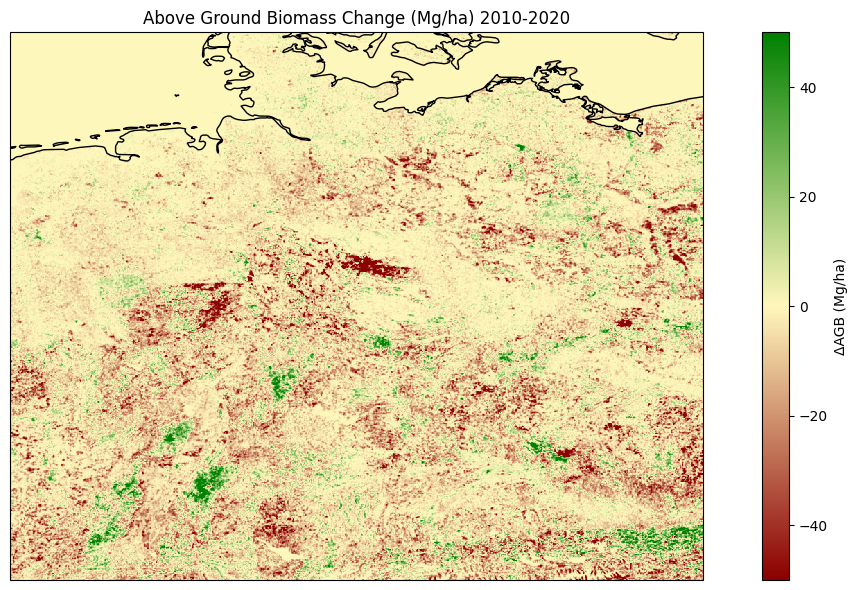

In [19]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import cartopy.crs as ccrs
import numpy as np

# Choose the plot's color map
# Options: 'red_yellow_green', 'red_white_green', 'red_orange_green', 'blue_white_red', 'brown_white_teal'
style = 'red_yellow_green'

# Customise color schemes
c_schemes = {
    'red_yellow_green': ["darkred", "#fff7bc", "green"],
    'red_white_green': ["red", "white", "green"],
    'red_orange_green': ["darkred", "orange", "darkgreen"],
    'blue_white_red': ["blue", "white", "red"],
    'brown_white_teal': ["brown", "white", "teal"]
}

# Load and extract the data
biomass = biomass_ds[variables[0]].squeeze().load()
lat = biomass_ds["lat"]
lon = biomass_ds["lon"]

# Choose the minimum and maximum values of the scale
vmin = -50
vmax = 50

start_year, end_year = data_id.split('-')[-2:]
dataset_year = f"{end_year}-{start_year}"

norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
colors = c_schemes.get(style, ["red", "yellow", "green"])
cmap = LinearSegmentedColormap.from_list('color_scheme', colors)

# Plot
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(region_box, crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    lon, lat, biomass,
    cmap=cmap, shading="auto",
    norm=norm
)

ax.coastlines()
plt.title(f"Above Ground Biomass Change (Mg/ha) {dataset_year}")
plt.colorbar(mesh, ax=ax, label="ΔAGB (Mg/ha)")
plt.tight_layout()
plt.show()